# Credit Card Fraud Detection — Classification Project

**Goal:** predict whether a credit card transaction is fraudulent using the anonymized
(PCA-transformed) transaction dataset.

**Steps covered in this notebook:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Train/test split (before any resampling, to avoid data leakage)
4. Preprocessing with `ColumnTransformer`
5. Handling class imbalance (SMOTE / undersampling)
6. Baseline model — Logistic Regression
7. SVM (RBF kernel)
8. Random Forest with hyperparameter tuning (`RandomizedSearchCV`)
9. Evaluation with classification metrics (with an explanation of each metric)
10. Model comparison and final recommendation


In [41]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Handling class imbalance — imblearn's Pipeline makes sure resampling
# only ever touches the TRAINING folds, never the test/validation data
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Evaluation
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Load & inspect the data

In [42]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [43]:
df.shape

(284807, 31)

In [44]:
# Check dtypes and get a statistical summary
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [45]:
# --- Missing value check ---
# The target column is never imputed: a row with no label can't be used for supervised
# learning, so it would be dropped if any were found.
missing = df.isnull().sum()
print("Missing values per column (only columns with >0 shown):")
print(missing[missing > 0] if missing.sum() > 0 else "None found.")

if df['Class'].isnull().sum() > 0:
    df = df.dropna(subset=['Class'])


Missing values per column (only columns with >0 shown):
None found.


In [46]:
# --- Duplicate check ---
# This dataset is known to contain duplicate rows. Leaving them in risks the same
# transaction appearing in both the train and test split, which would leak information
# and make the test score look better than it really is.
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows found: 1081
Shape after removing duplicates: (283726, 31)


## 2. Exploratory Data Analysis (EDA)

Only the plots that materially inform modeling decisions are included below: the class
imbalance itself (the core challenge of this dataset), how transaction amount differs
between fraud/non-fraud, and which features are most correlated with fraud.

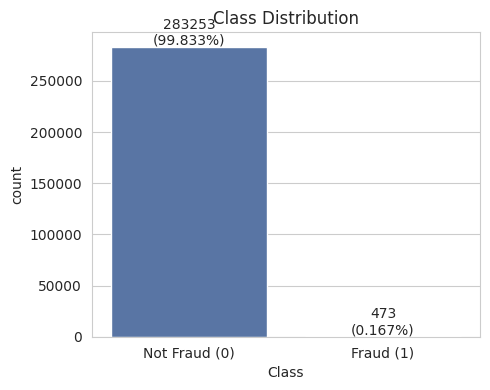

In [47]:
# Class balance — confirms the dataset is heavily imbalanced, which drives every modeling decision that follows (metric choice, resampling, etc.)
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='Class', hue='Class', data=df, palette=['#4C72B0', '#C44E52'],
              legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])
ax.set_title('Class Distribution')
for i, v in enumerate(class_counts):
    ax.text(i, v + 2000, f"{v}\n({class_pct[i]:.3f}%)", ha='center')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3493/4017429754.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_3493/4017429754.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Fraud', 'Fraud'])


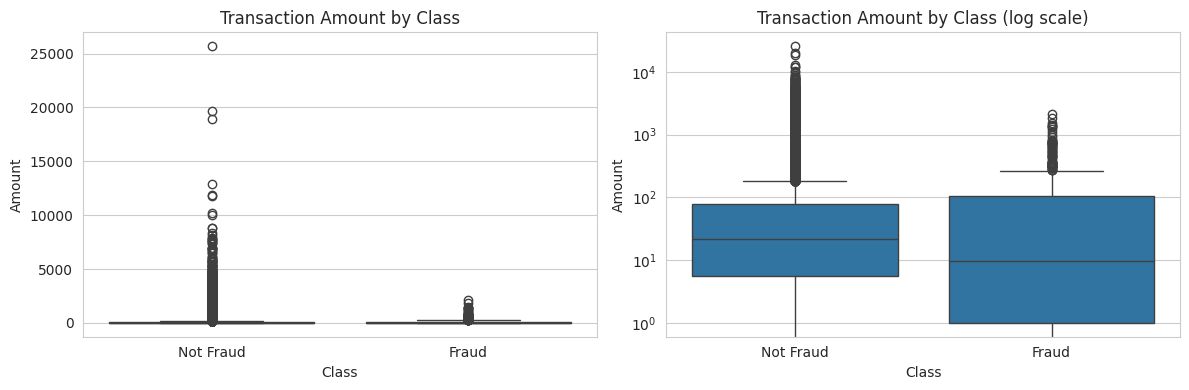

In [48]:
# Transaction amount by class — fraud amounts tend to differ from normal spending
# patterns, so this is worth checking as a candidate signal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

# Amount is heavily right-skewed, so a log scale makes the comparison readable
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount by Class (log scale)')
axes[1].set_xticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()


## 3. Train/test split

The split happens **before** any resampling. If SMOTE or scaling were fit on the full
dataset first, information from the test set would leak into training and the evaluation
scores would be artificially inflated.

In [49]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)  # stratify=y keeps the same ~0.17% fraud ratio in both splits

print("Train shape:", X_train.shape, " | Fraud ratio:", round(y_train.mean(), 5))
print("Test shape: ", X_test.shape, " | Fraud ratio:", round(y_test.mean(), 5))


Train shape: (226980, 30)  | Fraud ratio: 0.00167
Test shape:  (56746, 30)  | Fraud ratio: 0.00167


## 4. Preprocessing pipeline

`Time` and `Amount` are on very different scales from `V1`–`V28`, which already arrive
pre-scaled from the original PCA transform. Only `Time`/`Amount` need `StandardScaler`;
the rest pass through unchanged.

In [50]:
numeric_features = ['Time', 'Amount']
pca_features = [c for c in X.columns if c.startswith('V')]

preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), numeric_features)],
    remainder='passthrough'  # V1-V28 pass through unscaled (already PCA-scaled)
)


## 5. Handling class imbalance



## 6. Evaluation helper

The same evaluation is applied consistently to every model: a full classification report,
a confusion matrix, and every metric needed for the comparison at the end.

In [51]:
results = {}   # stores metrics per model, used for the final comparison table
roc_data = {}  # stores (fpr, tpr) per model, used for the ROC curve overlay
pr_data = {}   # stores (precision, recall) per model, used for the PR curve overlay

def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC (Avg Precision)': average_precision_score(y_test, y_proba),
    }
    results[name] = metrics
    roc_data[name] = roc_curve(y_test, y_proba)[:2]
    pr_data[name] = precision_recall_curve(y_test, y_proba)[:2]

    print(f"===== {name} =====")
    # Generate classification report as a dictionary to customize output
    report_dict = classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud'], digits=4, output_dict=True)


    print(f"{"" :<12}{"precision":>10}{"recall":>10}{"f1-score":>10}")
    print(f"{"Not Fraud":<12}{report_dict['Not Fraud']['precision']:>10.4f}{report_dict['Not Fraud']['recall']:>10.4f}{report_dict['Not Fraud']['f1-score']:>10.4f}")
    print(f"{"Fraud":<12}{report_dict['Fraud']['precision']:>10.4f}{report_dict['Fraud']['recall']:>10.4f}{report_dict['Fraud']['f1-score']:>10.4f}")
    print(f"\n{"accuracy":<12}{"":>10}{"":>10}{report_dict['accuracy']:>10.4f}")

    print() # Add a newline for separation
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Not Fraud', 'Fraud'], cmap='Blues'
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return y_proba

## 7. Baseline model — Logistic Regression

A simple, fast, interpretable linear model. This is the reference point every other model
needs to beat to justify its extra complexity.

===== Logistic Regression =====
             precision    recall  f1-score
Not Fraud       0.9998    0.9741    0.9868
Fraud           0.0535    0.8737    0.1009

accuracy                            0.9739

Accuracy: 0.9739
Precision: 0.0535
Recall: 0.8737
F1-score: 0.1009
ROC-AUC: 0.9618
PR-AUC (Avg Precision): 0.6766


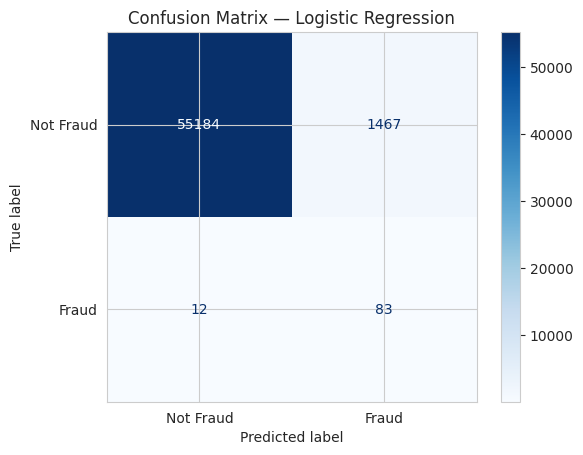

array([0.02149582, 0.01639285, 0.00737715, ..., 0.0424591 , 0.05501357,
       0.02007949])

In [52]:
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    # bring fraud up to 10% of the majority class rather than a full 50/50 balance
    ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
evaluate_model('Logistic Regression', lr_pipeline, X_test, y_test)


## 8. SVM (RBF kernel)




===== SVM =====
             precision    recall  f1-score
Not Fraud       0.9998    0.9883    0.9940
Fraud           0.1104    0.8632    0.1957

accuracy                            0.9881

Accuracy: 0.9881
Precision: 0.1104
Recall: 0.8632
F1-score: 0.1957
ROC-AUC: 0.9833
PR-AUC (Avg Precision): 0.6666


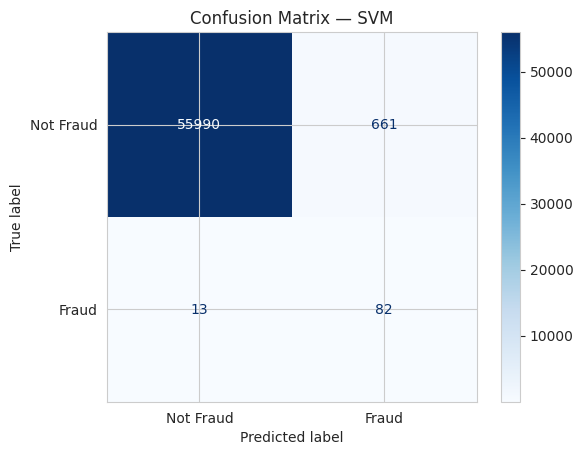

array([0.0051701 , 0.00221315, 0.01204775, ..., 0.0080992 , 0.01846109,
       0.0045282 ])

In [53]:
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('undersample', RandomUnderSampler(sampling_strategy=0.05, random_state=42)),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('classifier', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)),
])

svm_pipeline.fit(X_train, y_train)
evaluate_model('SVM', svm_pipeline, X_test, y_test)


## 9. Random Forest with hyperparameter tuning


In [54]:
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('undersample', RandomUnderSampler(sampling_strategy=0.05, random_state=42)),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [8, 12, 16, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    rf_pipeline, param_distributions=param_dist, n_iter=8, cv=3,
    scoring='average_precision', random_state=42, n_jobs=-1, verbose=1,
)
rf_search.fit(X_train, y_train)

print("Best parameters found:", rf_search.best_params_)
rf_best = rf_search.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 12}


===== Random Forest (Tuned) =====
             precision    recall  f1-score
Not Fraud       0.9997    0.9987    0.9992
Fraud           0.5200    0.8211    0.6367

accuracy                            0.9984

Accuracy: 0.9984
Precision: 0.5200
Recall: 0.8211
F1-score: 0.6367
ROC-AUC: 0.9773
PR-AUC (Avg Precision): 0.7108


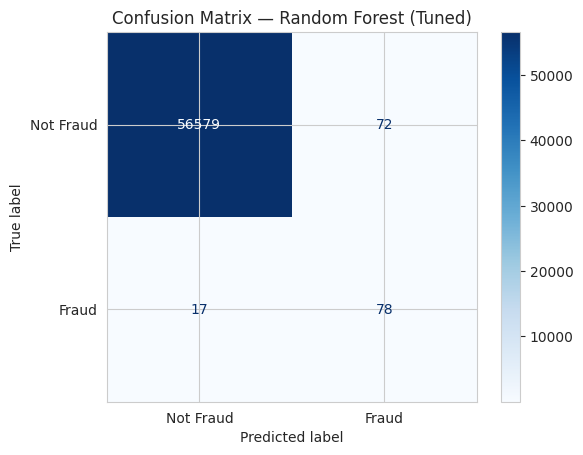

array([0.00215735, 0.0072303 , 0.09780109, ..., 0.00253551, 0.003657  ,
       0.02611754])

In [55]:
evaluate_model('Random Forest (Tuned)', rf_best, X_test, y_test)


## 10. Understanding the metrics

Fraud is only ~0.17% of transactions, so **accuracy is misleading on its own** — a model
that predicts "not fraud" for every transaction scores ~99.8% accuracy while catching zero


For fraud detection specifically, **recall and PR-AUC matter most** — missing real fraud
(a false negative) is usually far more costly than a false alarm (a false positive), which
just triggers a quick manual check.

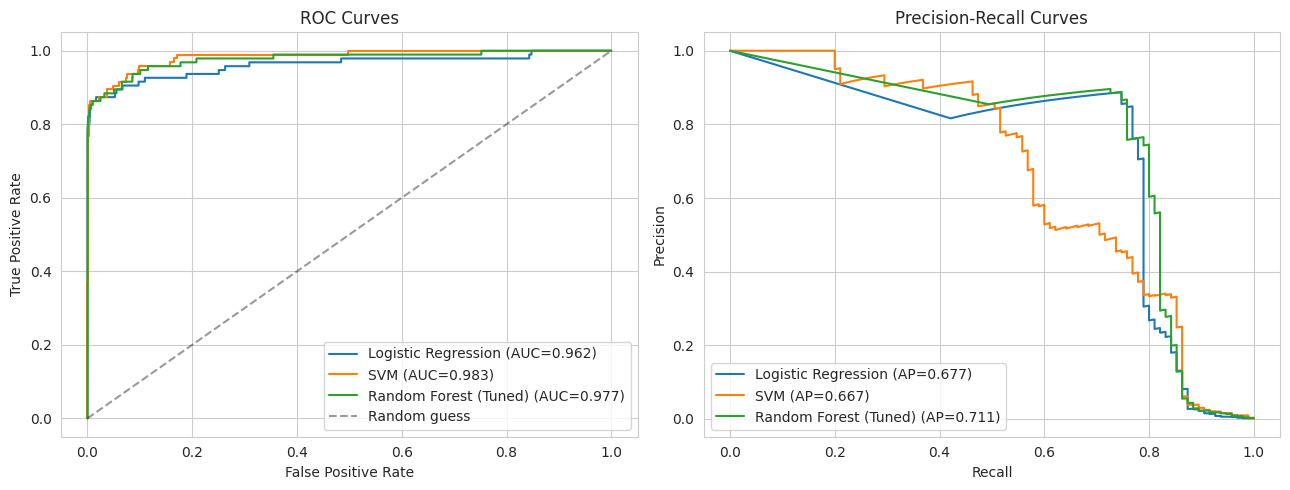

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (fpr, tpr) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

for name, (precision, recall) in pr_data.items():
    axes[1].plot(recall, precision,
                 label=f"{name} (AP={results[name]['PR-AUC (Avg Precision)']:.3f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Model comparison and final recommendation

In [57]:
results_df = pd.DataFrame(results).T.round(4)
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Avg Precision)
Logistic Regression,0.9739,0.0535,0.8737,0.1009,0.9618,0.6766
SVM,0.9881,0.1104,0.8632,0.1957,0.9833,0.6666
Random Forest (Tuned),0.9984,0.5200,0.8211,0.6367,0.9773,0.7108


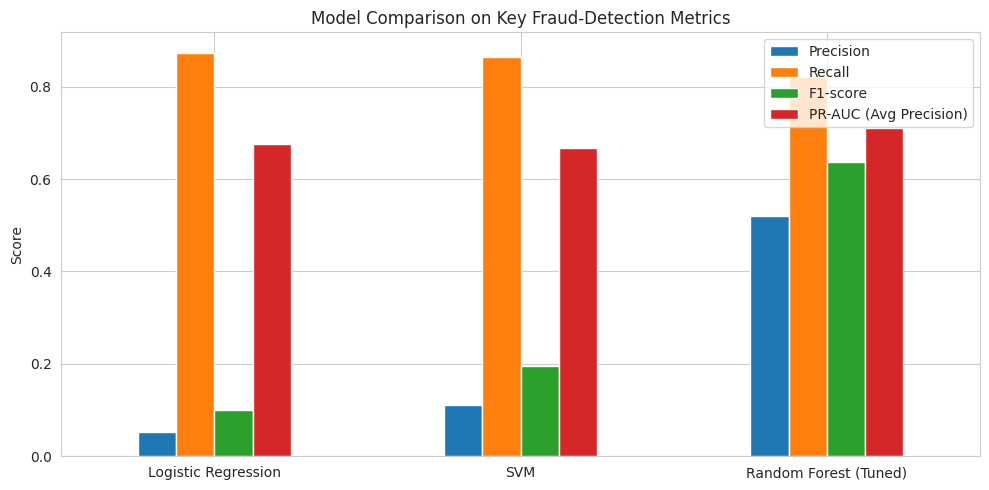

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df[['Precision', 'Recall', 'F1-score', 'PR-AUC (Avg Precision)']].plot(
    kind='bar', ax=ax
)
ax.set_title('Model Comparison on Key Fraud-Detection Metrics')
ax.set_ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [59]:
best_model = results_df['PR-AUC (Avg Precision)'].idxmax()
print(f"Best model by PR-AUC (Average Precision): {best_model}\n")
print(results_df.loc[best_model])


Best model by PR-AUC (Average Precision): Random Forest (Tuned)

Accuracy                  0.9984
Precision                 0.5200
Recall                    0.8211
F1-score                  0.6367
ROC-AUC                   0.9773
PR-AUC (Avg Precision)    0.7108
Name: Random Forest (Tuned), dtype: float64
